In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [ ]:
def analyze_sweep(npz_path, title="", save_path=None, alpha=0.05):
    data = np.load(npz_path)
    v_grid, p_grid = data["v_grid"], data["p_grid"]
    seeds = data["seeds"] if "seeds" in data else None
    policy_names = [k for k in data.keys() if k not in ("v_grid", "p_grid", "seeds", "n_completed", "total")]
    n_seeds = len(seeds) if seeds is not None else data[policy_names[0]].shape[0]
    n_v, n_p = len(v_grid), len(p_grid)

    # stacked shape: (n_policy, n_seeds, n_v, n_p)
    stacked = np.stack([data[name] for name in policy_names], axis=0)
    mean_regret = stacked.mean(axis=1)  # (n_policy, n_v, n_p)

    winner_idx = np.zeros((n_v, n_p), dtype=int)
    pvalue_grid = np.zeros((n_v, n_p))

    for i in range(n_v):
        for j in range(n_p):
            order = np.argsort(mean_regret[:, i, j])  # ascending regret, best first
            best, second = order[0], order[1]
            winner_idx[i, j] = best
            a, b = stacked[best, :, i, j], stacked[second, :, i, j]
            if np.allclose(a, b):
                pvalue_grid[i, j] = 1.0
            else:
                _, pvalue_grid[i, j] = stats.ttest_rel(a, b)

    significant = pvalue_grid < alpha
    n_cells = significant.size

    # ---------------- metrics table ----------------
    print(f"\n{'='*72}\n{title or npz_path}\n{'='*72}")
    print(f"grid: {n_v} x {n_p} = {n_cells} cells, n_seeds={n_seeds}\n")
    print(f"Statistically confident winner (p<{alpha}): {significant.sum()} / {n_cells} ({100*significant.mean():.1f}%)")
    print(f"Effectively tied with runner-up (p>={alpha}):  {(~significant).sum()} / {n_cells} ({100*(~significant).mean():.1f}%)\n")

    print(f"{'policy':<15s} {'cells won':>10s} {'win %':>8s} {'sig. wins':>10s} {'mean regret (grid-wide)':>26s} {'median regret':>15s}")
    for idx, name in enumerate(policy_names):
        won_mask = (winner_idx == idx)
        n_won = won_mask.sum()
        n_sig_won = (won_mask & significant).sum()
        grid_mean = mean_regret[idx].mean()
        grid_median = np.median(mean_regret[idx])
        print(f"{name:<15s} {n_won:>10d} {100*n_won/n_cells:>7.1f}% {n_sig_won:>10d} {grid_mean:>26.3f} {grid_median:>15.3f}")
    print()

    # ---------------- plot ----------------
    fig, ax = plt.subplots(figsize=(9, 7))
    cmap = plt.get_cmap("tab10", len(policy_names))
    im = ax.pcolormesh(p_grid, v_grid, winner_idx, shading="auto", cmap=cmap,
                        vmin=-0.5, vmax=len(policy_names) - 0.5)
    ax.set_yscale("log")

    not_sig_p = [p_grid[j] for i in range(n_v) for j in range(n_p) if not significant[i, j]]
    not_sig_v = [v_grid[i] for i in range(n_v) for j in range(n_p) if not significant[i, j]]
    ax.scatter(not_sig_p, not_sig_v, marker="x", color="black", s=25, linewidths=1.2,
               label=f"not significant (p>={alpha})")

    ax.set_xlabel("p (core unavailability prob.)")
    ax.set_ylabel("v (rise rate, log scale)")
    ax.set_title(f"{title or npz_path}\nWinner per cell ({n_seeds} seeds)")
    ax.legend(loc="upper right", fontsize=8)
    cbar = fig.colorbar(im, ax=ax, ticks=range(len(policy_names)))
    cbar.ax.set_yticklabels(policy_names)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"saved {save_path}")
    plt.show()

    return dict(winner_idx=winner_idx, pvalue_grid=pvalue_grid, significant=significant,
                mean_regret=mean_regret, policy_names=policy_names, v_grid=v_grid, p_grid=p_grid)


Baseline mu1 < mu2
grid: 16 x 16 = 256 cells, n_seeds=100

Statistically confident winner (p<0.05): 225 / 256 (87.9%)
Effectively tied with runner-up (p>=0.05):  31 / 256 (12.1%)

policy           cells won    win %  sig. wins    mean regret (grid-wide)   median regret
Greedy                  53    20.7%         44                    143.512          68.558
ETC(c=1)                37    14.5%         25                    139.261          58.808
ETC(c=2)                12     4.7%         12                    150.475          87.750
ETC(c=3)                46    18.0%         43                    165.819         131.550
UCB1                    10     3.9%          7                    140.081          71.498
Thompson                98    38.3%         94                    140.873          65.539

saved ./results


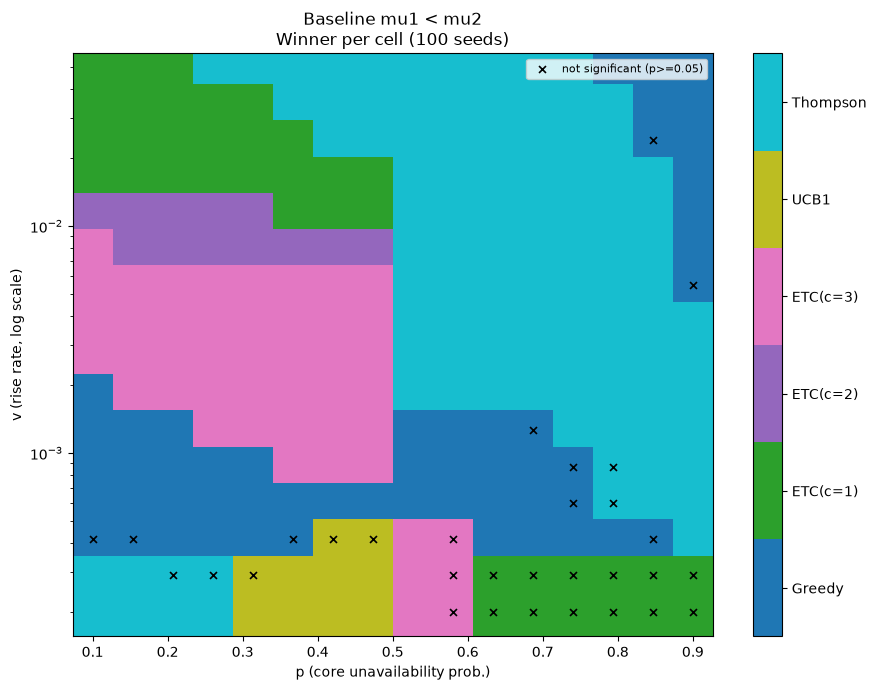

{'winner_idx': array([[5, 5, 5, 5, 4, 4, 4, 4, 3, 3, 1, 1, 1, 1, 1, 1],
        [5, 5, 5, 5, 4, 4, 4, 4, 3, 3, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 4, 4, 3, 3, 0, 0, 0, 0, 0, 5],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 5, 5],
        [0, 0, 0, 0, 0, 3, 3, 3, 0, 0, 0, 0, 0, 5, 5, 5],
        [0, 0, 0, 3, 3, 3, 3, 3, 0, 0, 0, 0, 5, 5, 5, 5],
        [0, 3, 3, 3, 3, 3, 3, 3, 5, 5, 5, 5, 5, 5, 5, 5],
        [3, 3, 3, 3, 3, 3, 3, 3, 5, 5, 5, 5, 5, 5, 5, 5],
        [3, 3, 3, 3, 3, 3, 3, 3, 5, 5, 5, 5, 5, 5, 5, 5],
        [3, 3, 3, 3, 3, 3, 3, 3, 5, 5, 5, 5, 5, 5, 5, 0],
        [3, 2, 2, 2, 2, 2, 2, 2, 5, 5, 5, 5, 5, 5, 5, 0],
        [2, 2, 2, 2, 2, 1, 1, 1, 5, 5, 5, 5, 5, 5, 5, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 5, 5, 5, 5, 5, 5, 5, 0],
        [1, 1, 1, 1, 1, 1, 5, 5, 5, 5, 5, 5, 5, 5, 0, 0],
        [1, 1, 1, 1, 1, 5, 5, 5, 5, 5, 5, 5, 5, 5, 0, 0],
        [1, 1, 1, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 0, 0, 0]]),
 'pvalue_grid': array([[3.06612147e-004, 3.07790957e-004

In [ ]:
analyze_sweep("./results/modal_case1_baseline.npz", title="Baseline mu1 < mu2", save_path="./results")


./modal_case2_final.npz
grid: 16 x 16 = 256 cells, n_seeds=100

Statistically confident winner (p<0.05): 109 / 256 (42.6%)
Effectively tied with runner-up (p>=0.05):  147 / 256 (57.4%)

policy           cells won    win %  sig. wins    mean regret (grid-wide)   median regret
Greedy                  95    37.1%         78                      0.138           0.102
ETC(c=1)                96    37.5%          0                     17.801           1.355
ETC(c=2)                 0     0.0%          0                     34.722           2.419
ETC(c=3)                32    12.5%         16                     50.872           3.543
UCB1                    27    10.5%         13                      0.213           0.065
Thompson                 6     2.3%          2                      0.275           0.187



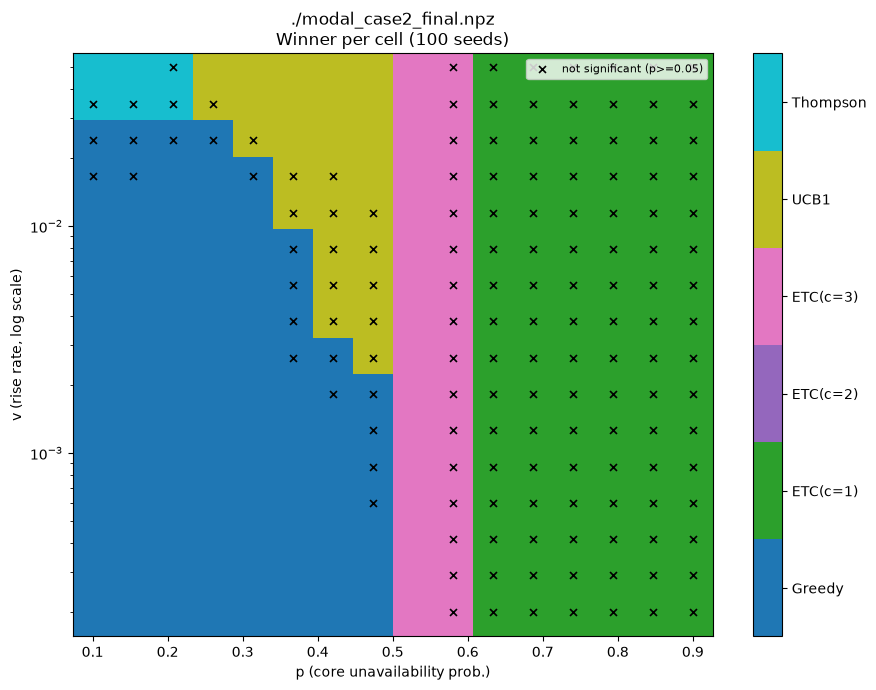

In [ ]:
r2 = analyze_sweep("./results/modal_case2_final.npz")

In [ ]:
# using the dict returned by analyze_sweep() -- call it e.g. r2 = analyze_sweep(...)
p_grid = r2["p_grid"]
mean_regret = r2["mean_regret"]  # shape (n_policy, n_v, n_p)
policy_names = r2["policy_names"]

high_p_mask = p_grid > 0.5  # roughly where the green region + X's live
print("Mean regret WITHIN the high-p region only:")
for idx, name in enumerate(policy_names):
    vals = mean_regret[idx][:, high_p_mask]
    print(f"  {name:>12s}: mean={vals.mean():.4f}  max={vals.max():.4f}")

Mean regret WITHIN the high-p region only:
        Greedy: mean=0.0655  max=0.5804
      ETC(c=1): mean=0.0153  max=0.2874
      ETC(c=2): mean=0.0062  max=0.1157
      ETC(c=3): mean=0.0026  max=0.0492
          UCB1: mean=0.0254  max=0.1556
      Thompson: mean=0.2083  max=0.5472



./modal_case1_full.npz
grid: 16 x 16 = 256 cells, n_seeds=100

Statistically confident winner (p<0.05): 230 / 256 (89.8%)
Effectively tied with runner-up (p>=0.05):  26 / 256 (10.2%)

policy           cells won    win %  sig. wins    mean regret (grid-wide)   median regret
Greedy                  40    15.6%         34                    143.512          68.558
ETC(c=1)                37    14.5%         25                    139.261          58.808
ETC(c=2)                 2     0.8%          2                    150.475          87.750
ETC(c=3)                11     4.3%          8                    165.819         131.550
UCB1                    10     3.9%          7                    140.081          71.498
Thompson                67    26.2%         65                    140.873          65.539
RecencyUCB              89    34.8%         89                     99.606          77.384



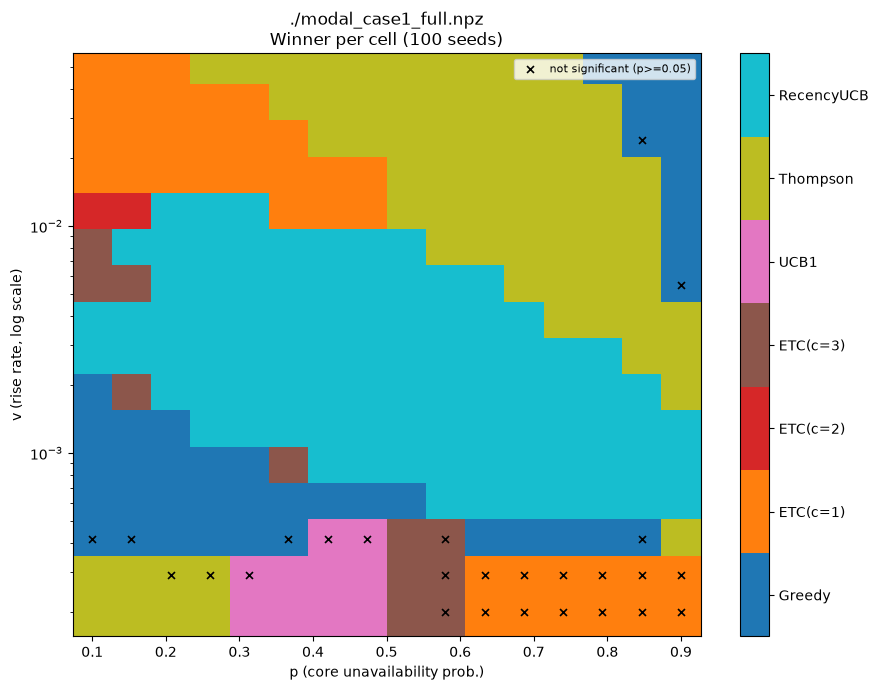

{'winner_idx': array([[5, 5, 5, 5, 4, 4, 4, 4, 3, 3, 1, 1, 1, 1, 1, 1],
        [5, 5, 5, 5, 4, 4, 4, 4, 3, 3, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 4, 4, 3, 3, 0, 0, 0, 0, 0, 5],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 6, 6, 6, 6, 6, 6],
        [0, 0, 0, 0, 0, 3, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6],
        [0, 0, 0, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6],
        [0, 3, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5],
        [6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5, 5],
        [6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5, 5, 5, 5],
        [3, 3, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5, 5, 5, 5, 0],
        [3, 6, 6, 6, 6, 6, 6, 6, 6, 5, 5, 5, 5, 5, 5, 0],
        [2, 2, 6, 6, 6, 1, 1, 1, 5, 5, 5, 5, 5, 5, 5, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 5, 5, 5, 5, 5, 5, 5, 0],
        [1, 1, 1, 1, 1, 1, 5, 5, 5, 5, 5, 5, 5, 5, 0, 0],
        [1, 1, 1, 1, 1, 5, 5, 5, 5, 5, 5, 5, 5, 5, 0, 0],
        [1, 1, 1, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 0, 0, 0]]),
 'pvalue_grid': array([[3.06612147e-004, 3.07790957e-004

In [ ]:
analyze_sweep("./results/modal_case1_full.npz")


./modal_case2_full.npz
grid: 16 x 16 = 256 cells, n_seeds=100

Statistically confident winner (p<0.05): 109 / 256 (42.6%)
Effectively tied with runner-up (p>=0.05):  147 / 256 (57.4%)

policy           cells won    win %  sig. wins    mean regret (grid-wide)   median regret
Greedy                  95    37.1%         78                      0.138           0.102
ETC(c=1)                96    37.5%          0                     17.801           1.355
ETC(c=2)                 0     0.0%          0                     34.722           2.419
ETC(c=3)                32    12.5%         16                     50.872           3.543
UCB1                    27    10.5%         13                      0.213           0.065
Thompson                 6     2.3%          2                      0.275           0.187
RecencyUCB               0     0.0%          0                      1.529           0.279



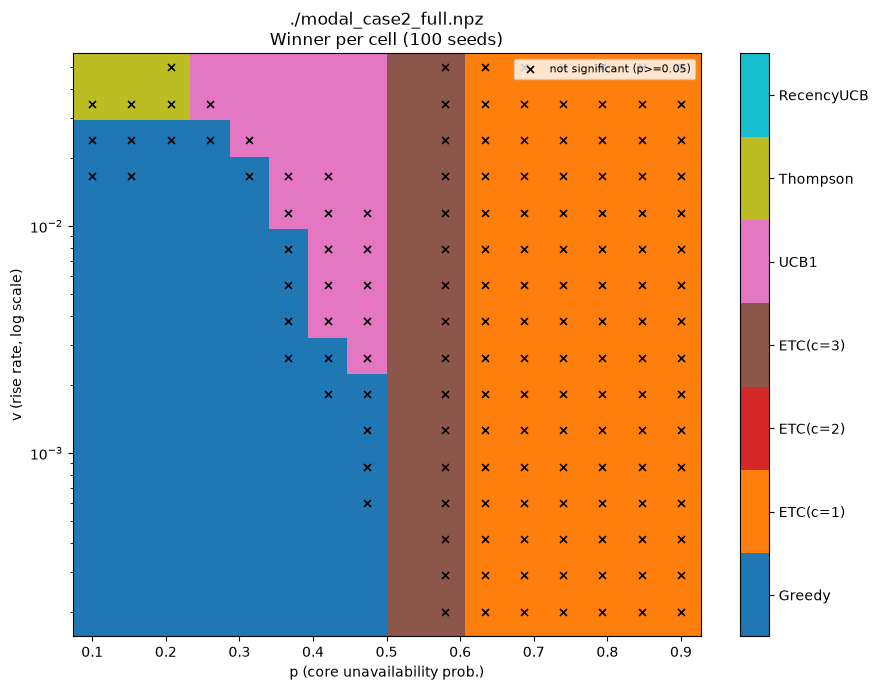

{'winner_idx': array([[0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 4, 3, 3, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 4, 4, 3, 3, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 4, 4, 3, 3, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 4, 4, 3, 3, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 4, 4, 4, 3, 3, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 4, 4, 4, 3, 3, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 4, 4, 4, 4, 3, 3, 1, 1, 1, 1, 1, 1],
        [5, 5, 5, 4, 4, 4, 4, 4, 3, 3, 1, 1, 1, 1, 1, 1],
        [5, 5, 5, 4, 4, 4, 4, 4, 3, 3, 1, 1, 1, 1, 1, 1]]),
 'pvalue_grid': array([[1.74668047e-012, 1.27905916e-014

In [ ]:
analyze_sweep("./results/modal_case2_full.npz")